|                |   |
:----------------|---|
| **Nombre**     Elisa Aguirre|   |
| **Fecha**      5/02/25|   |
| **Expediente** 738894 |   |

# EDA

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\elisa\Downloads\brain_tumor_dataset.csv")
df.head()

,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,1,73,Male,Malignant,5.375612,Temporal,Astrocytoma,III,Vision Issues,Seizures,Seizures,No,No,No,51.312579,0.111876,No,Positive,Yes
1,2,26,Male,Benign,4.847098,Parietal,Glioblastoma,II,Headache,Headache,Nausea,Yes,Yes,Yes,46.373273,2.165736,Yes,Positive,Yes
2,3,31,Male,Benign,5.588391,Parietal,Meningioma,I,Vision Issues,Headache,Seizures,No,No,No,47.072221,1.884228,No,Negative,No
3,4,29,Male,Malignant,1.436600,Temporal,Medulloblastoma,IV,Vision Issues,Seizures,Headache,Yes,No,Yes,51.853634,1.283342,Yes,Negative,No
4,5,54,Female,Benign,2.417506,Parietal,Glioblastoma,I,Headache,Headache,Seizures,No,No,Yes,54.708987,2.069477,No,Positive,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           20000 non-null  int64  
 1   Age                  20000 non-null  int64  
 2   Gender               20000 non-null  object 
 3   Tumor_Type           20000 non-null  object 
 4   Tumor_Size           20000 non-null  float64
 5   Location             20000 non-null  object 
 6   Histology            20000 non-null  object 
 7   Stage                20000 non-null  object 
 8   Symptom_1            20000 non-null  object 
 9   Symptom_2            20000 non-null  object 
 10  Symptom_3            20000 non-null  object 
 11  Radiation_Treatment  20000 non-null  object 
 12  Surgery_Performed    20000 non-null  object 
 13  Chemotherapy         20000 non-null  object 
 14  Survival_Rate        20000 non-null  float64
 15  Tumor_Growth_Rate    20000 non-null 

In [4]:
df.describe()

,Patient_ID,Age,Tumor_Size,Survival_Rate,Tumor_Growth_Rate
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,49.433700,5.236552,70.131699,1.547701
std,5773.647028,17.389296,2.754359,17.270834,0.835995
min,1.000000,20.000000,0.500410,40.002386,0.100017
25%,5000.750000,34.000000,2.836686,55.224439,0.830433
50%,10000.500000,49.000000,5.200675,70.305066,1.541821
75%,15000.250000,65.000000,7.624299,85.043395,2.262484
max,20000.000000,79.000000,9.999420,99.998125,2.999835


**Numéricas:** Age, Tumor_Size, Survival_Rate, Tumor_Growth_Rate
* Int: Age
* Float: Tumor_Size, Survival_Rate, Tumor_Growth_Rate

**Categóricas:** Gender, Tumor_Type, Location, Histology, Stage, Symptom_1, Symptom_2, Symptom_3, Radiation_Treatment, Surgery_Performed, Chemotherapy, Family_History, Follow_Up_Required, MRI_Result

**Categóticas ordinales:** Stage

**Booleanas:** Radiation_Treatment, Surgery_Performed, Chemotherapy, Family_History, Follow_Up_Required, Gender

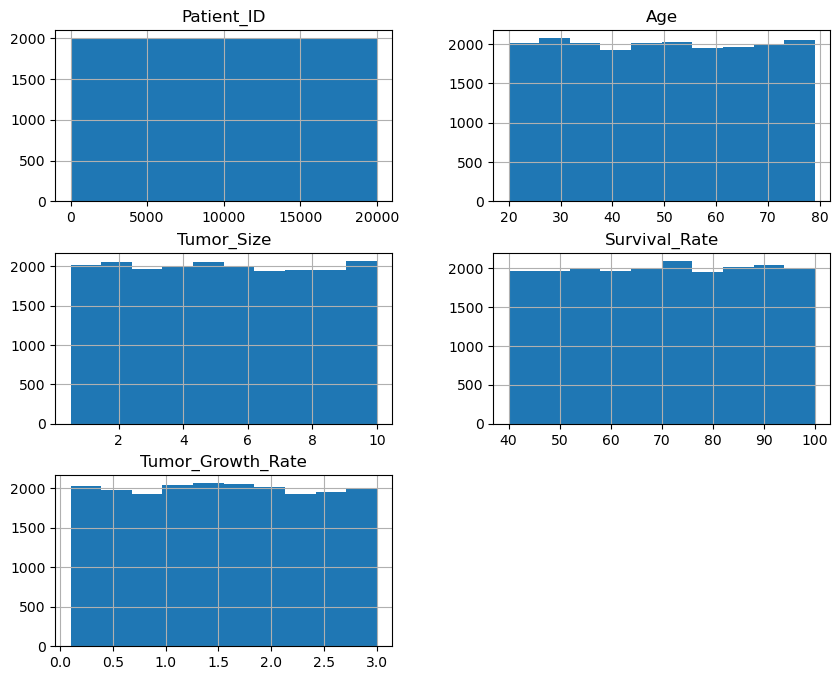

In [5]:
import matplotlib.pyplot as plt

df.hist(figsize=(10,8))
plt.show()

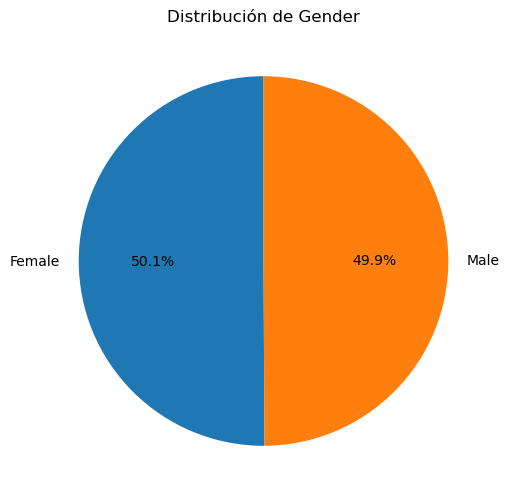

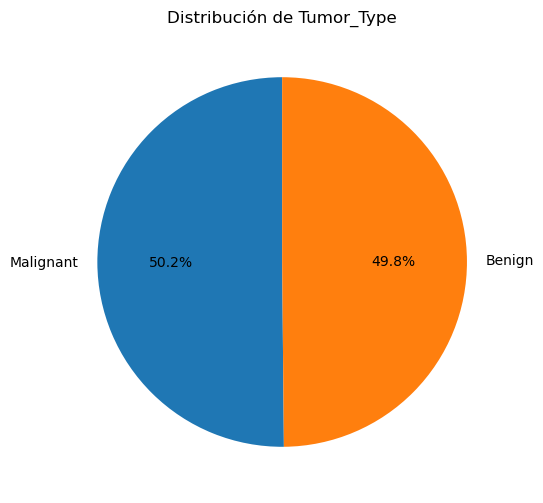

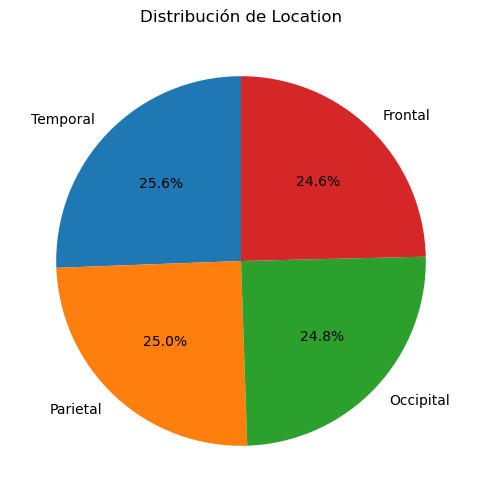

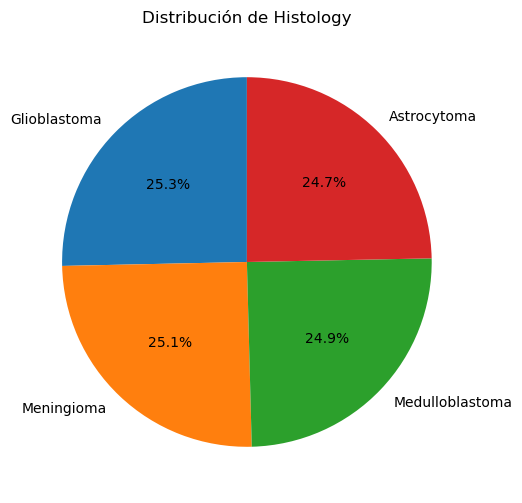

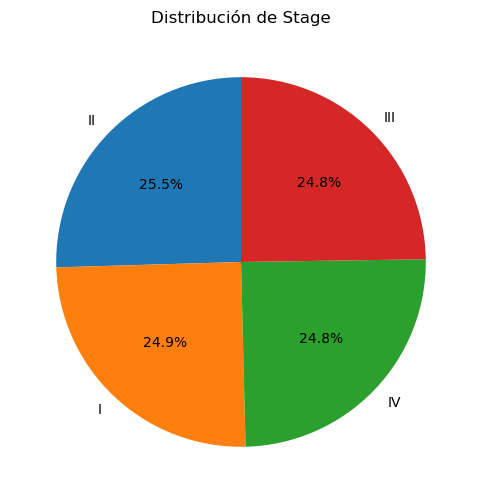

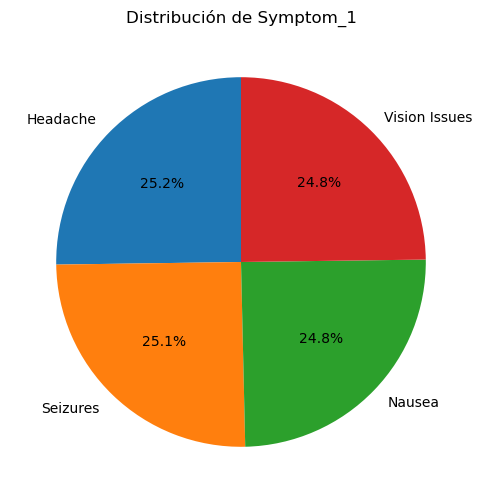

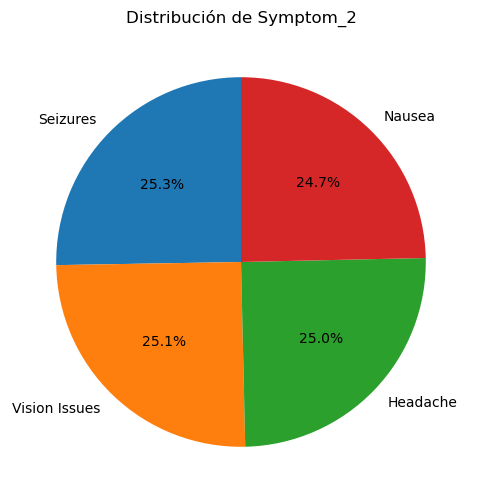

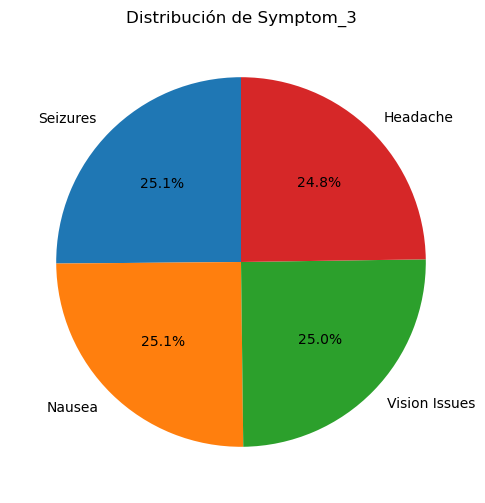

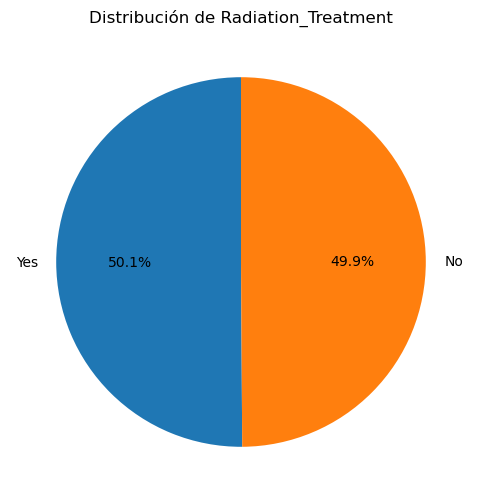

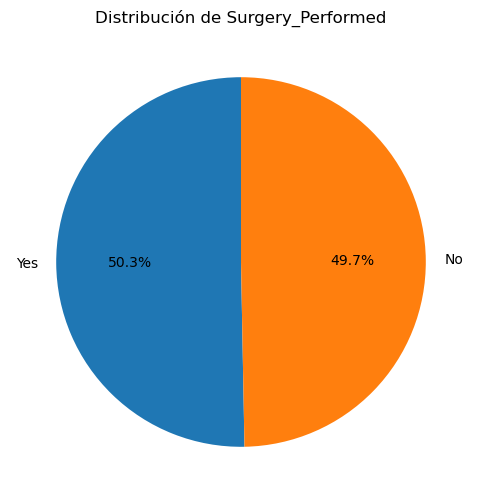

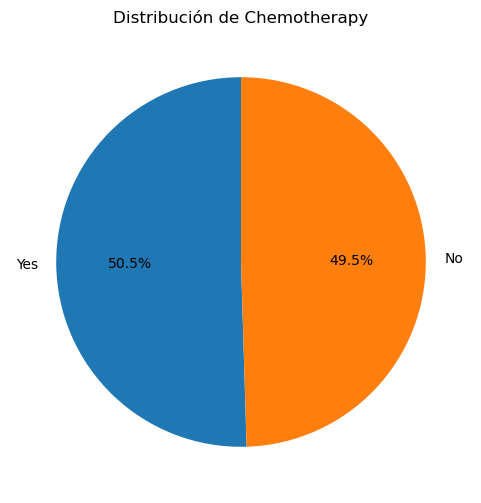

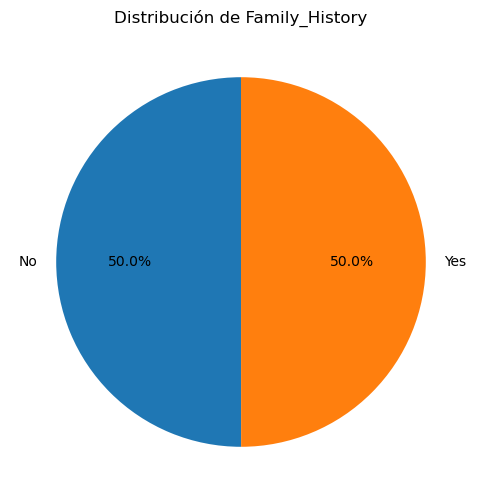

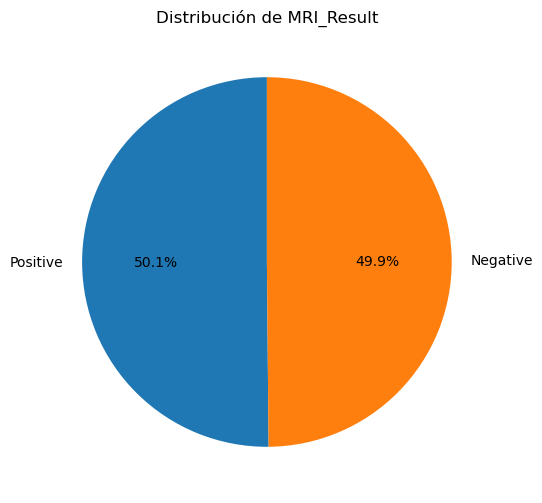

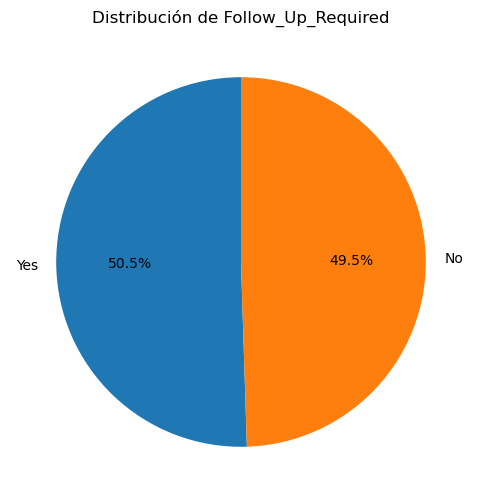

In [6]:
import matplotlib.pyplot as plt
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    plt.figure(figsize=(6,6))
    df[col].value_counts().plot(
        kind="pie",
        autopct="%1.1f%%",  
        startangle=90)
    plt.title(f"Distribución de {col}")
    plt.ylabel("")  
    plt.show()

**¿Cuántas personas recibieron tratamiento de radiación, cirugía y quimioterapia?**

In [7]:
((df["Radiation_Treatment"] == "Yes") & (df["Surgery_Performed"] == "Yes") & (df["Chemotherapy"] == "Yes")).sum()

np.int64(2590)

In [8]:
df = df.drop(columns=["Patient_ID","Symptom_1","Symptom_2","Symptom_3"])

In [9]:
y = df["Tumor_Type"]  
x = df.drop("Tumor_Type", axis=1)

In [10]:
num = ["Age", "Tumor_Size", "Survival_Rate", "Tumor_Growth_Rate"]
ordi = ["Stage"] 
cat = ["Gender", "Location", "Histology","MRI_Result"]
bools = ["Surgery_Performed", "Radiation_Treatment", "Chemotherapy","Family_History","Follow_Up_Required"]

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num),
        ("ord", OrdinalEncoder(categories=[["I", "II", "III", "IV"]]), ordi),
        ("cat", OneHotEncoder(), cat),
        ("bool", OneHotEncoder(), bools)
    ]
)

In [12]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
model = SVC(kernel="linear", probability=True)
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [ ]:
pipeline.fit(x,y)